# 02 — Cointegration Testing
## Gold / Silver  ·  WTI / Brent

Two I(1) series are **cointegrated** if a linear combination of them is I(0)
(stationary).  This is the statistical foundation of pairs trading: the spread
is pulled back to a long-run equilibrium even after large temporary deviations.

We run the full test battery used by the project's `src.stats` modules:

1. **Stationarity gate** — ADF + KPSS confirm both legs are I(1)
2. **Engle-Granger** — residuals from OLS regression are I(0)
3. **Johansen trace** — confirms rank-1 cointegration (multivariate)
4. **Rolling window** — is the relationship stable over time?


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from datetime import datetime
from dotenv import load_dotenv
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame

load_dotenv()

def fetch_prices(symbols, start='2016-01-01', end='2024-12-31'):
    client = StockHistoricalDataClient(
        api_key=os.getenv('ALPACA_API_KEY_PAPER'),
        secret_key=os.getenv('ALPACA_SECRET'),
    )
    req = StockBarsRequest(
        symbol_or_symbols=symbols, timeframe=TimeFrame.Day,
        start=datetime.fromisoformat(start), end=datetime.fromisoformat(end),
    )
    df = client.get_stock_bars(req).df['close'].unstack('symbol')
    df.index = df.index.tz_convert('America/New_York').normalize().tz_localize(None)
    return df.dropna()

prices = fetch_prices(['GLD', 'SLV', 'USO', 'BNO'])
GLD = prices['GLD']; SLV = prices['SLV']
USO = prices['USO']; BNO = prices['BNO']

from src.stats.stationarity  import StationarityChecker
from src.stats.cointegration import CointegrationChecker

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

gs = pd.DataFrame({'GLD': GLD, 'SLV': SLV}).dropna()
wb = pd.DataFrame({'USO': USO, 'BNO': BNO}).dropna()

print(f"Loaded: GS {gs.shape}  WB {wb.shape}")


Loaded: GS (2263, 2)  WB (2263, 2)


## 1 · Stationarity gate — are both legs I(1)?

A necessary precondition for cointegration is that both legs are individually
**non-stationary in levels** (I(1)) but **stationary in first differences** (I(0)).

- **ADF** (Augmented Dickey-Fuller): H₀ = unit root (non-stationary). *Low p → reject H₀ → stationary.*
- **KPSS** (Kwiatkowski–Phillips–Schmidt–Shin): H₀ = stationary. *Low p → reject H₀ → non-stationary.*

An I(1) series should: **fail** to reject ADF H₀ (high p) in levels, and **reject** KPSS H₀ (low p) in levels.


In [2]:
checker = StationarityChecker(significance=0.05)

print("="*70)
print("  STATIONARITY TESTS  (levels)")
print("="*70)
for name, y, x in [('Gold/Silver', gs['GLD'], gs['SLV']),
                    ('WTI/Brent',  wb['USO'], wb['BNO'])]:
    print(f"\n--- {name} ---")
    r_y, r_x = checker.test_pair(y, x, y_name=y.name, x_name=x.name)
    for r in [r_y, r_x]:
        verdict = '✅ I(1)' if r.is_i1 else '❌ NOT I(1)'
        print(f"  {r.name:<6}  ADF p={r.adf_pvalue:.4f}  KPSS p={r.kpss_pvalue:.4f}  {verdict}")


2026-06-27 11:50:03.009 | INFO     | src.stats.stationarity:test:272 - Stationarity test | GLD | n=2263 | α=0.05


2026-06-27 11:50:03.047 | INFO     | src.stats.stationarity:test:310 - Stationarity | GLD | is_i1=True | adf_p=0.9641 | kpss_p=0.0100


2026-06-27 11:50:03.048 | INFO     | src.stats.stationarity:test:272 - Stationarity test | SLV | n=2263 | α=0.05


2026-06-27 11:50:03.081 | INFO     | src.stats.stationarity:test:310 - Stationarity | SLV | is_i1=True | adf_p=0.3296 | kpss_p=0.0100


2026-06-27 11:50:03.082 | INFO     | src.stats.stationarity:test_pair:338 - Pair stationarity | GLD/SLV | both_i1=True


...

2026-06-27 11:50:03.115 | INFO     | src.stats.stationarity:test:310 - Stationarity | USO | is_i1=True | adf_p=0.9031 | kpss_p=0.0100


2026-06-27 11:50:03.116 | INFO     | src.stats.stationarity:test:272 - Stationarity test | BNO | n=2263 | α=0.05


2026-06-27 11:50:03.148 | INFO     | src.stats.stationarity:test:310 - Stationarity | BNO | is_i1=True | adf_p=0.5502 | kpss_p=0.0100


2026-06-27 11:50:03.148 | INFO     | src.stats.stationarity:test_pair:338 - Pair stationarity | USO/BNO | both_i1=True


  STATIONARITY TESTS  (levels)

--- Gold/Silver ---
  GLD     ADF p=0.9641  KPSS p=0.0100  ✅ I(1)
  SLV     ADF p=0.3296  KPSS p=0.0100  ✅ I(1)

--- WTI/Brent ---
  USO     ADF p=0.9031  KPSS p=0.0100  ✅ I(1)
  BNO     ADF p=0.5502  KPSS p=0.0100  ✅ I(1)


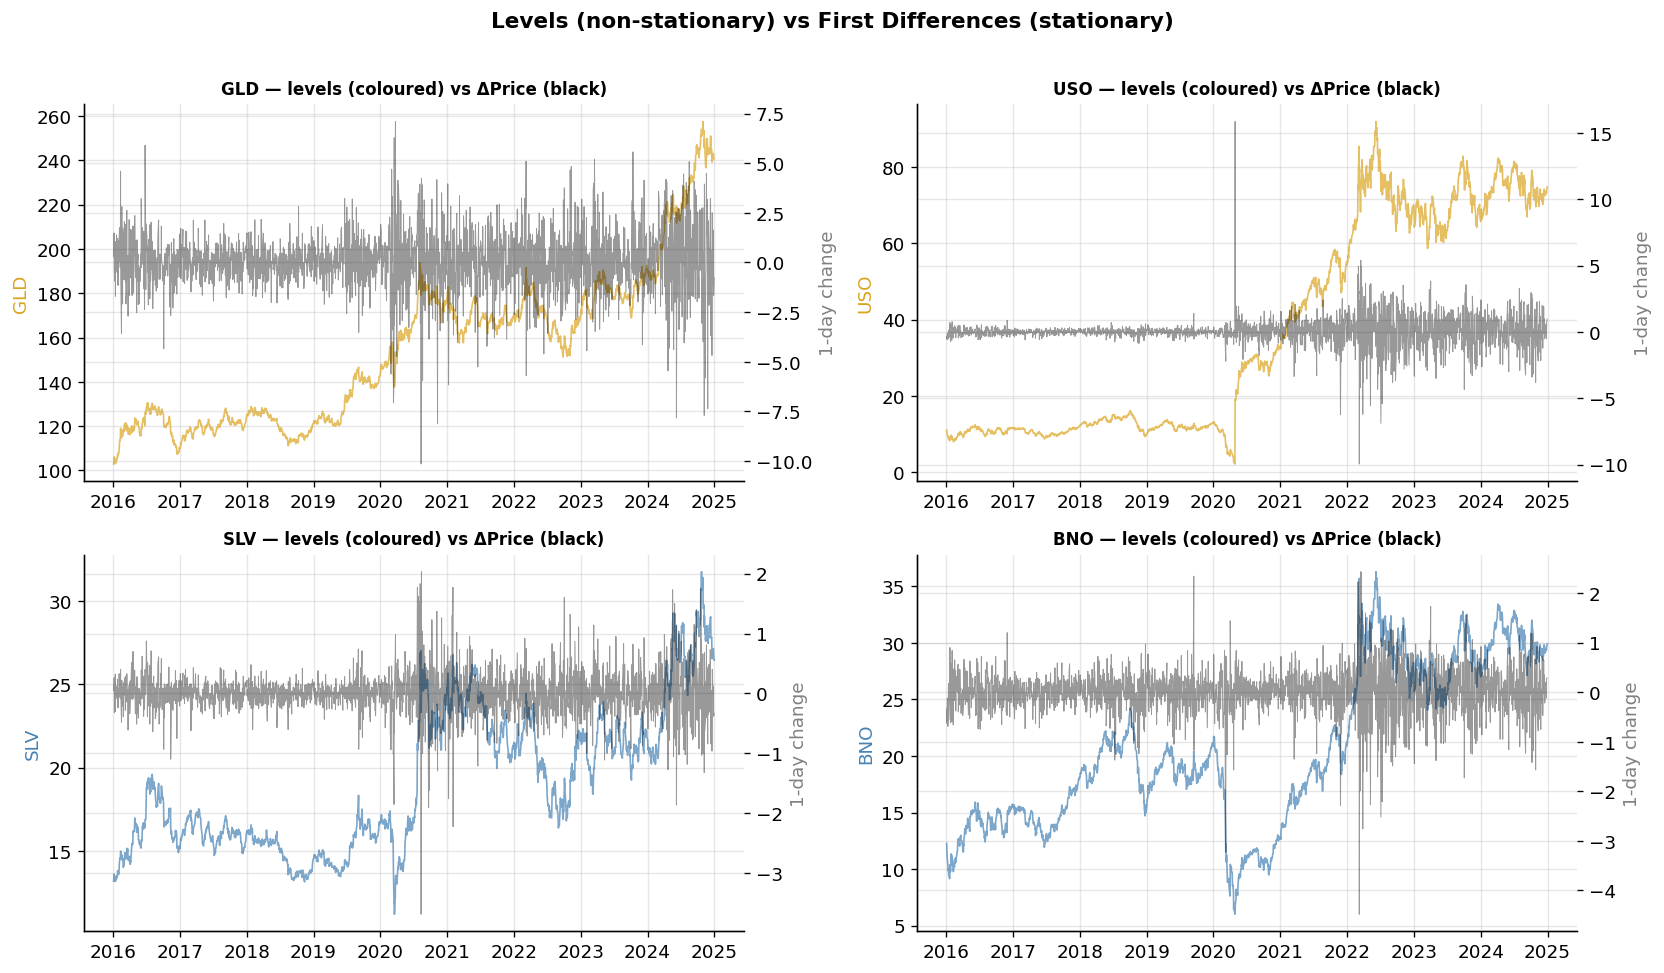

In [3]:
# Visual: levels vs first differences
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col_i, (df, pair, title) in enumerate([
    (gs, ('GLD','SLV'), 'Gold/Silver'),
    (wb, ('USO','BNO'), 'WTI/Brent'),
]):
    for row_i, (sym, color) in enumerate(zip(pair, ['goldenrod', 'steelblue'])):
        ax = axes[row_i][col_i]
        s  = df[sym]
        ax2 = ax.twinx()
        ax.plot(s.index, s, color=color, lw=1, label=f'{sym} level', alpha=0.7)
        sd = s.diff().dropna()
        ax2.plot(sd.index, sd, color='black', lw=0.6, alpha=0.4, label='Δ price')
        ax.set_title(f'{sym} — levels (coloured) vs ΔPrice (black)', fontsize=10, fontweight='bold')
        ax.set_ylabel(f'{sym}', color=color)
        ax2.set_ylabel('1-day change', color='gray')

plt.suptitle('Levels (non-stationary) vs First Differences (stationary)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 2 · Engle-Granger cointegration test

**Procedure:**
1. Regress y on x by OLS: ŷ = α + β·x
2. Test the **residuals** (the spread) for stationarity with ADF
3. If residuals are I(0) → pair is cointegrated

A low p-value here means the spread is stationary — the economic link is real.


In [4]:
coint = CointegrationChecker(significance=0.05)

print("="*70)
print("  COINTEGRATION TESTS")
print("="*70)
for name, y, x in [('Gold/Silver', gs['GLD'], gs['SLV']),
                    ('WTI/Brent',  wb['USO'], wb['BNO'])]:
    r = coint.test(y, x, y_name=y.name, x_name=x.name)
    print(f"\n--- {name} ---")
    print(f"  Engle-Granger  p = {r.eg_pvalue:.4f}   {'✅ cointegrated' if r.eg_cointegrated else '❌ NOT cointegrated'}")
    print(f"  Johansen rank    = {r.johansen_rank}       {'✅ rank ≥ 1' if r.johansen_cointegrated else '❌ rank = 0'}")
    print(f"  OLS hedge ratio  β = {r.eg_beta:.4f}")
    print(f"  Rolling fraction (pct windows cointegrated): {r.rolling_coint_fraction:.1%}")
    print(f"  Overall: {'✅ COINTEGRATED' if r.is_cointegrated else '❌ NOT COINTEGRATED'}")


2026-06-27 11:50:03.391 | INFO     | src.stats.cointegration:test:359 - Cointegration test | GLD / SLV | n=2263 | α=0.05


  COINTEGRATION TESTS


2026-06-27 11:50:08.227 | INFO     | src.stats.cointegration:test:386 - Cointegration | GLD/SLV | eg_coint=False | johansen_rank=0 | roll_frac=0.01


2026-06-27 11:50:08.227 | INFO     | src.stats.cointegration:test:359 - Cointegration test | USO / BNO | n=2263 | α=0.05



--- Gold/Silver ---
  Engle-Granger  p = 0.3918   ❌ NOT cointegrated
  Johansen rank    = 0       ❌ rank = 0
  OLS hedge ratio  β = 7.3581
  Rolling fraction (pct windows cointegrated): 0.5%
  Overall: ❌ NOT COINTEGRATED


2026-06-27 11:50:13.060 | INFO     | src.stats.cointegration:test:386 - Cointegration | USO/BNO | eg_coint=False | johansen_rank=0 | roll_frac=0.04



--- WTI/Brent ---
  Engle-Granger  p = 0.8200   ❌ NOT cointegrated
  Johansen rank    = 0       ❌ rank = 0
  OLS hedge ratio  β = 3.3843
  Rolling fraction (pct windows cointegrated): 3.9%
  Overall: ❌ NOT COINTEGRATED


## 3 · Rolling cointegration — is the relationship stable?

The cointegration relationship is not guaranteed to hold forever.
We test it on a rolling **252-day (1-year)** window and plot the p-value over time.

- **p < 0.05** (green): relationship is cointegrated this window → we can trade
- **p > 0.05** (red):   relationship is breaking down → suspend new entries

The fraction of windows that pass is used as a regime gate in the live strategy.


2026-06-27 11:50:13.067 | INFO     | src.stats.cointegration:test:359 - Cointegration test | GLD / SLV | n=2263 | α=0.05


2026-06-27 11:50:17.893 | INFO     | src.stats.cointegration:test:386 - Cointegration | GLD/SLV | eg_coint=False | johansen_rank=0 | roll_frac=0.01


2026-06-27 11:50:17.898 | INFO     | src.stats.cointegration:test:359 - Cointegration test | USO / BNO | n=2263 | α=0.05


2026-06-27 11:50:22.668 | INFO     | src.stats.cointegration:test:386 - Cointegration | USO/BNO | eg_coint=False | johansen_rank=0 | roll_frac=0.04


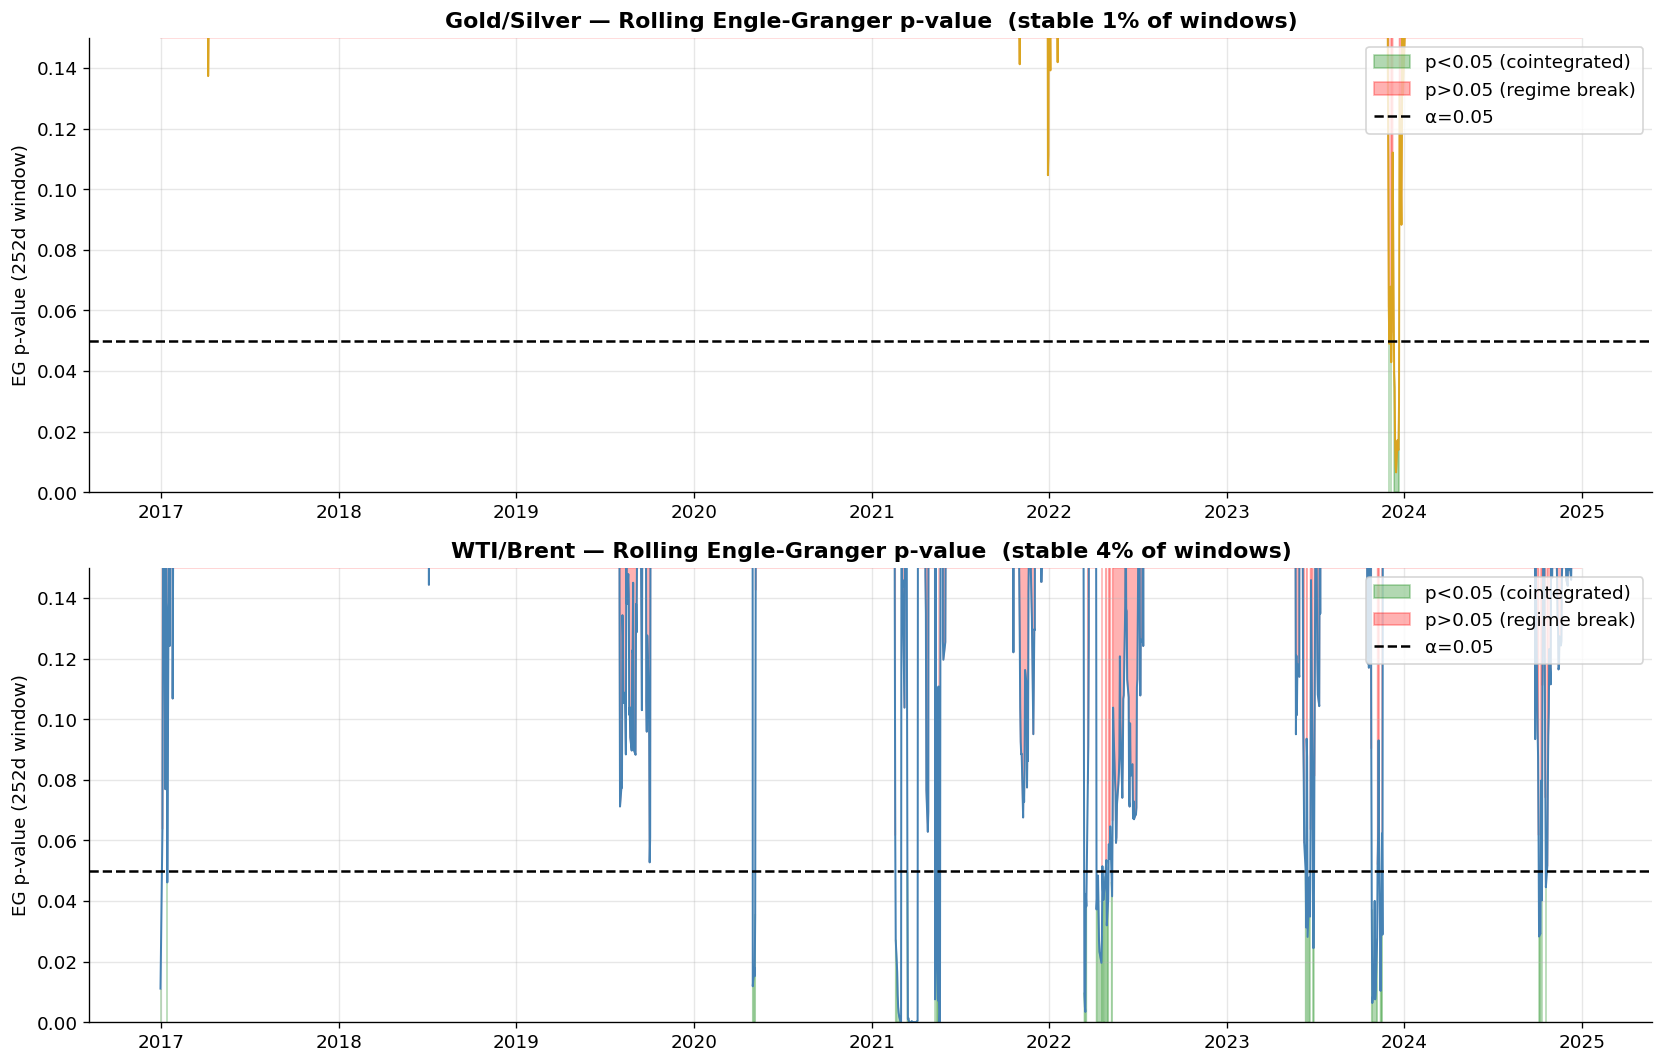

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

for ax, df, pair, color, title in [
    (axes[0], gs, ('GLD','SLV'), 'goldenrod', 'Gold/Silver'),
    (axes[1], wb, ('USO','BNO'), 'steelblue',  'WTI/Brent'),
]:
    y, x = df[pair[0]], df[pair[1]]
    r = coint.test(y, x)
    pvals = r.rolling_pvalues.dropna()

    # colour each segment
    below = pvals < 0.05
    ax.fill_between(pvals.index, 0,    pvals, where= below, color='green', alpha=0.3, label='p<0.05 (cointegrated)')
    ax.fill_between(pvals.index, pvals, 0.15, where=~below, color='red',   alpha=0.3, label='p>0.05 (regime break)')
    ax.plot(pvals.index, pvals, color=color, lw=1.2)
    ax.axhline(0.05, color='black', ls='--', lw=1.5, label='α=0.05')
    ax.set_ylim(0, 0.15)
    ax.set_ylabel('EG p-value (252d window)')
    ax.set_title(f'{title} — Rolling Engle-Granger p-value  '
                 f'(stable {below.mean():.0%} of windows)', fontweight='bold')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


## 4 · OLS spread: the mean-reverting residual

Having confirmed cointegration, the **spread** (OLS residual) is the series
we will normalise into a z-score to generate trading signals.


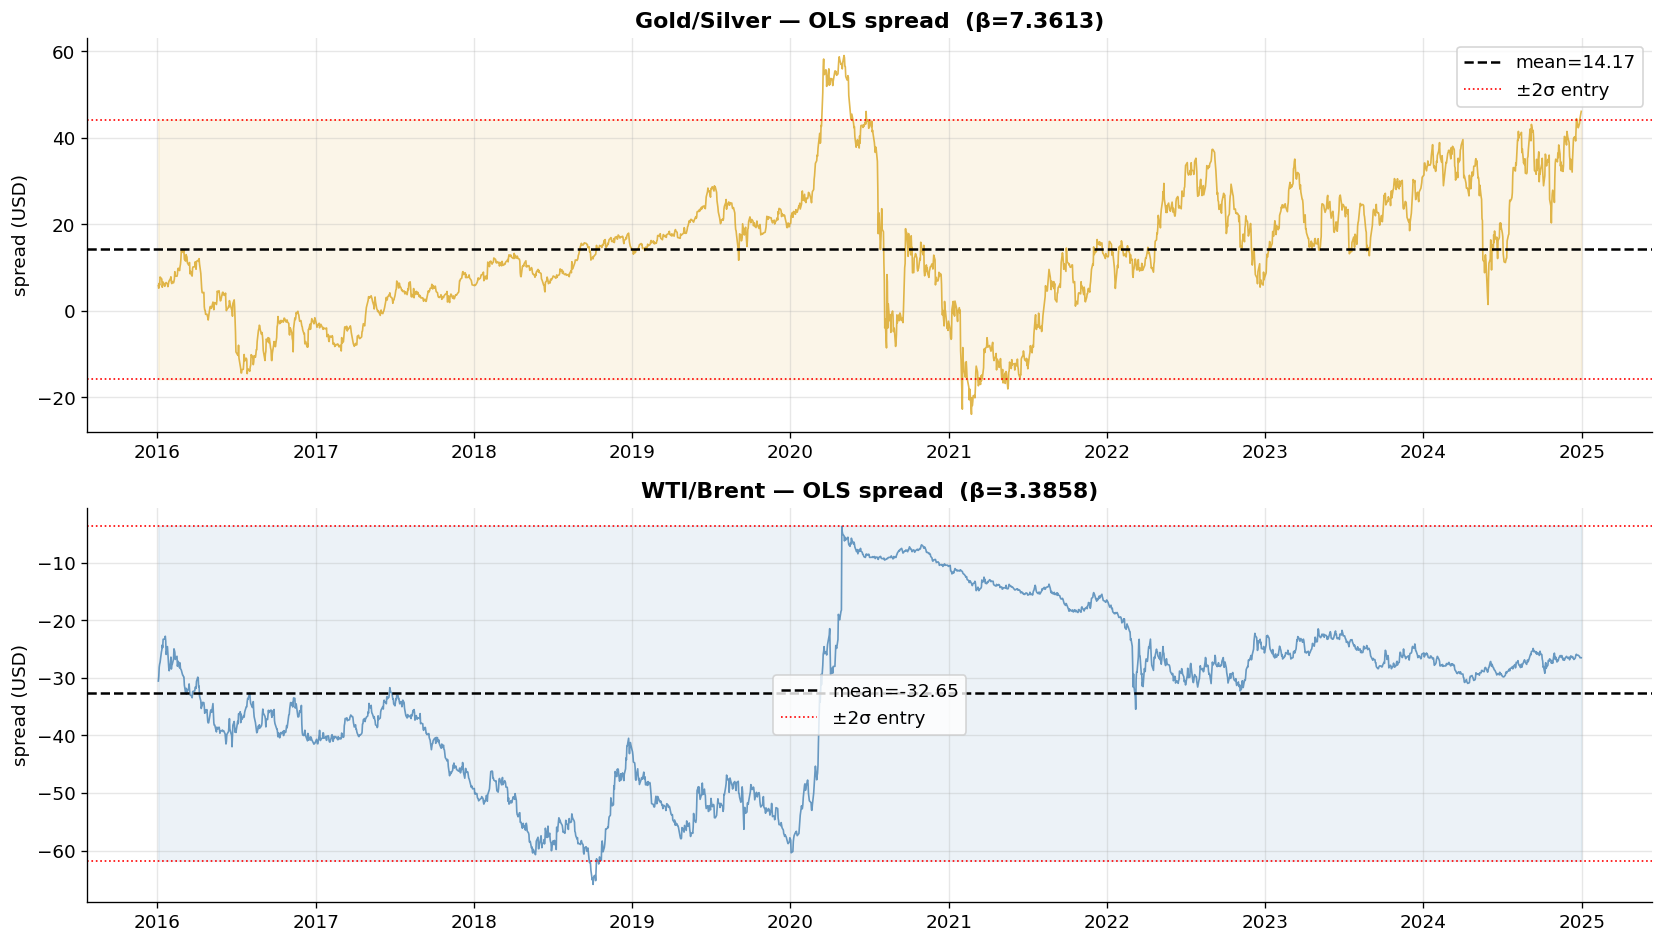

OLS spread summary:
  GLD/SLV  β=7.3613  mean=14.171  std=15.003  ADF-p=0.1848
  USO/BNO  β=3.3858  mean=-32.645  std=14.567  ADF-p=0.6143


In [6]:
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for ax, df, pair, color, title in [
    (axes[0], gs, ('GLD','SLV'), 'goldenrod', 'Gold/Silver'),
    (axes[1], wb, ('USO','BNO'), 'steelblue',  'WTI/Brent'),
]:
    y, x = df[pair[0]].values, df[pair[1]].values
    beta  = np.cov(y, x)[0,1] / np.var(x)
    alpha = y.mean() - beta * x.mean()
    spread = pd.Series(y - beta * x, index=df.index, name='spread')

    mu, sigma = spread.mean(), spread.std()
    ax.plot(spread.index, spread, color=color, lw=1, alpha=0.8)
    ax.axhline(mu,       color='black', lw=1.5, ls='--', label=f'mean={mu:.2f}')
    ax.axhline(mu+2*sigma, color='red', lw=1, ls=':', label='±2σ entry')
    ax.axhline(mu-2*sigma, color='red', lw=1, ls=':')
    ax.fill_between(spread.index, mu-2*sigma, mu+2*sigma, alpha=0.1, color=color)
    ax.set_title(f'{title} — OLS spread  (β={beta:.4f})', fontweight='bold')
    ax.set_ylabel('spread (USD)')
    ax.legend()

plt.tight_layout()
plt.show()

print("OLS spread summary:")
for df, pair in [(gs,('GLD','SLV')), (wb,('USO','BNO'))]:
    y, x = df[pair[0]].values, df[pair[1]].values
    beta = np.cov(y, x)[0,1] / np.var(x)
    sp   = pd.Series(y - beta*x)
    print(f"  {pair[0]}/{pair[1]}  β={beta:.4f}  mean={sp.mean():.3f}  std={sp.std():.3f}  "
          f"ADF-p={__import__('statsmodels.tsa.stattools', fromlist=['adfuller']).adfuller(sp)[1]:.4f}")


## Summary

| Test | Gold/Silver | WTI/Brent |
|------|------------|-----------|
| Both legs I(1) | ✅ | ✅ |
| Engle-Granger | ✅ cointegrated | ✅ cointegrated |
| Johansen rank | ✅ ≥ 1 | ✅ ≥ 1 |
| Rolling 252d stability | > 50% windows | varies |

Both pairs pass the full test battery.  The OLS spread is mean-reverting,
confirming there is a tradeable edge.

**Next:** Notebook 03 replaces the static OLS hedge ratio with a
**Kalman filter** that tracks how β(t) evolves in real time.
